## Supplementary figures and statistics concerning the atmospheric correction of MWR Tb measurements using RTTOV

The Sentinel-3 (S3) MWR Tbs were corrected for atmopsheric effects using the RTTOV radiative transfer model assuming a nadir viewing angle. The inputs to the RTM were as follows:

S3:
- latitude
- longitude

ERA5:

[surface level variables]
- 2m temperature
- skin temperature
- 10m wind u-component
- 10m wind v-component
- Sea Surface Temperature
- Sea ice concentration
- Surface pressure

[model level variables]
- Temperature
- Specific humidity
- Cloud liquid water content
- Cloud ice water content
- Specific rain water content
- Specific snow water content
- Fraction of Cloud Cover


TELSEM2:
- MW emissivity

By differening an 'all-sky' RTM run with a 'reference' run which has only the radiative contribution of temperature, we obtain the atmospheric contribution to the signal for each channel. This is added to the raw observations as a correction factor.

In [1]:
import sys
sys.path.append('/home/cn/NaRRS')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from Utility.utility_functions import get_tp_ds

Here, we break down the typical atmospheric correction applied to the MWR Tbs in our time period and main region of interest (above 55 $^\circ$ N). I have already generated a two csv files containing the Tb correction statistics, one with with monthly-aggregated statistics and one with seasonally monthly-aggregated statistics (Oct-Apr). In each case, the statistics are catagorized by the local SIC conditions, where:
- Open water refers to SIC = 0% 
- Mixed surface refers to 0% < SIC < 95
- Closed Ice refers to SIC ≥ 95%

## Tb Correction Time series

In [2]:
hemisphere = 'nh'
min_lat = 55

monthly_df = pd.read_csv(f'../Data/sentinel3_monthly_surface_mean_atmos_corr_{hemisphere}_above{min_lat}N.csv')
monthly_df['Year'] = monthly_df['YearMonth'].str[:4].astype(int)
monthly_df['Month'] = monthly_df['YearMonth'].str[5:7].astype(int)
monthly_df['Month_start'] = pd.to_datetime(monthly_df['YearMonth'], format='%Y-%m')
monthly_df['Frequency'] = monthly_df['Frequency'].astype(float)/10.

In [3]:
#lets fill the summer months with nan for plotting purposes
months = pd.date_range(start='2016-10-01', end='2024-04-01', freq='MS')
frequencies = [23.8, 36.5]
surfaces = ['Closed Ice', 'Mixed', 'Open Water']

#create all combinations
all_combinations = pd.MultiIndex.from_product(
	[months, frequencies, surfaces],
	names=['Month_start', 'Frequency', 'Surface Flag']
).to_frame(index=False)

monthly_df = pd.merge(all_combinations, monthly_df, on=['Month_start','Frequency', 'Surface Flag'], how='outer')

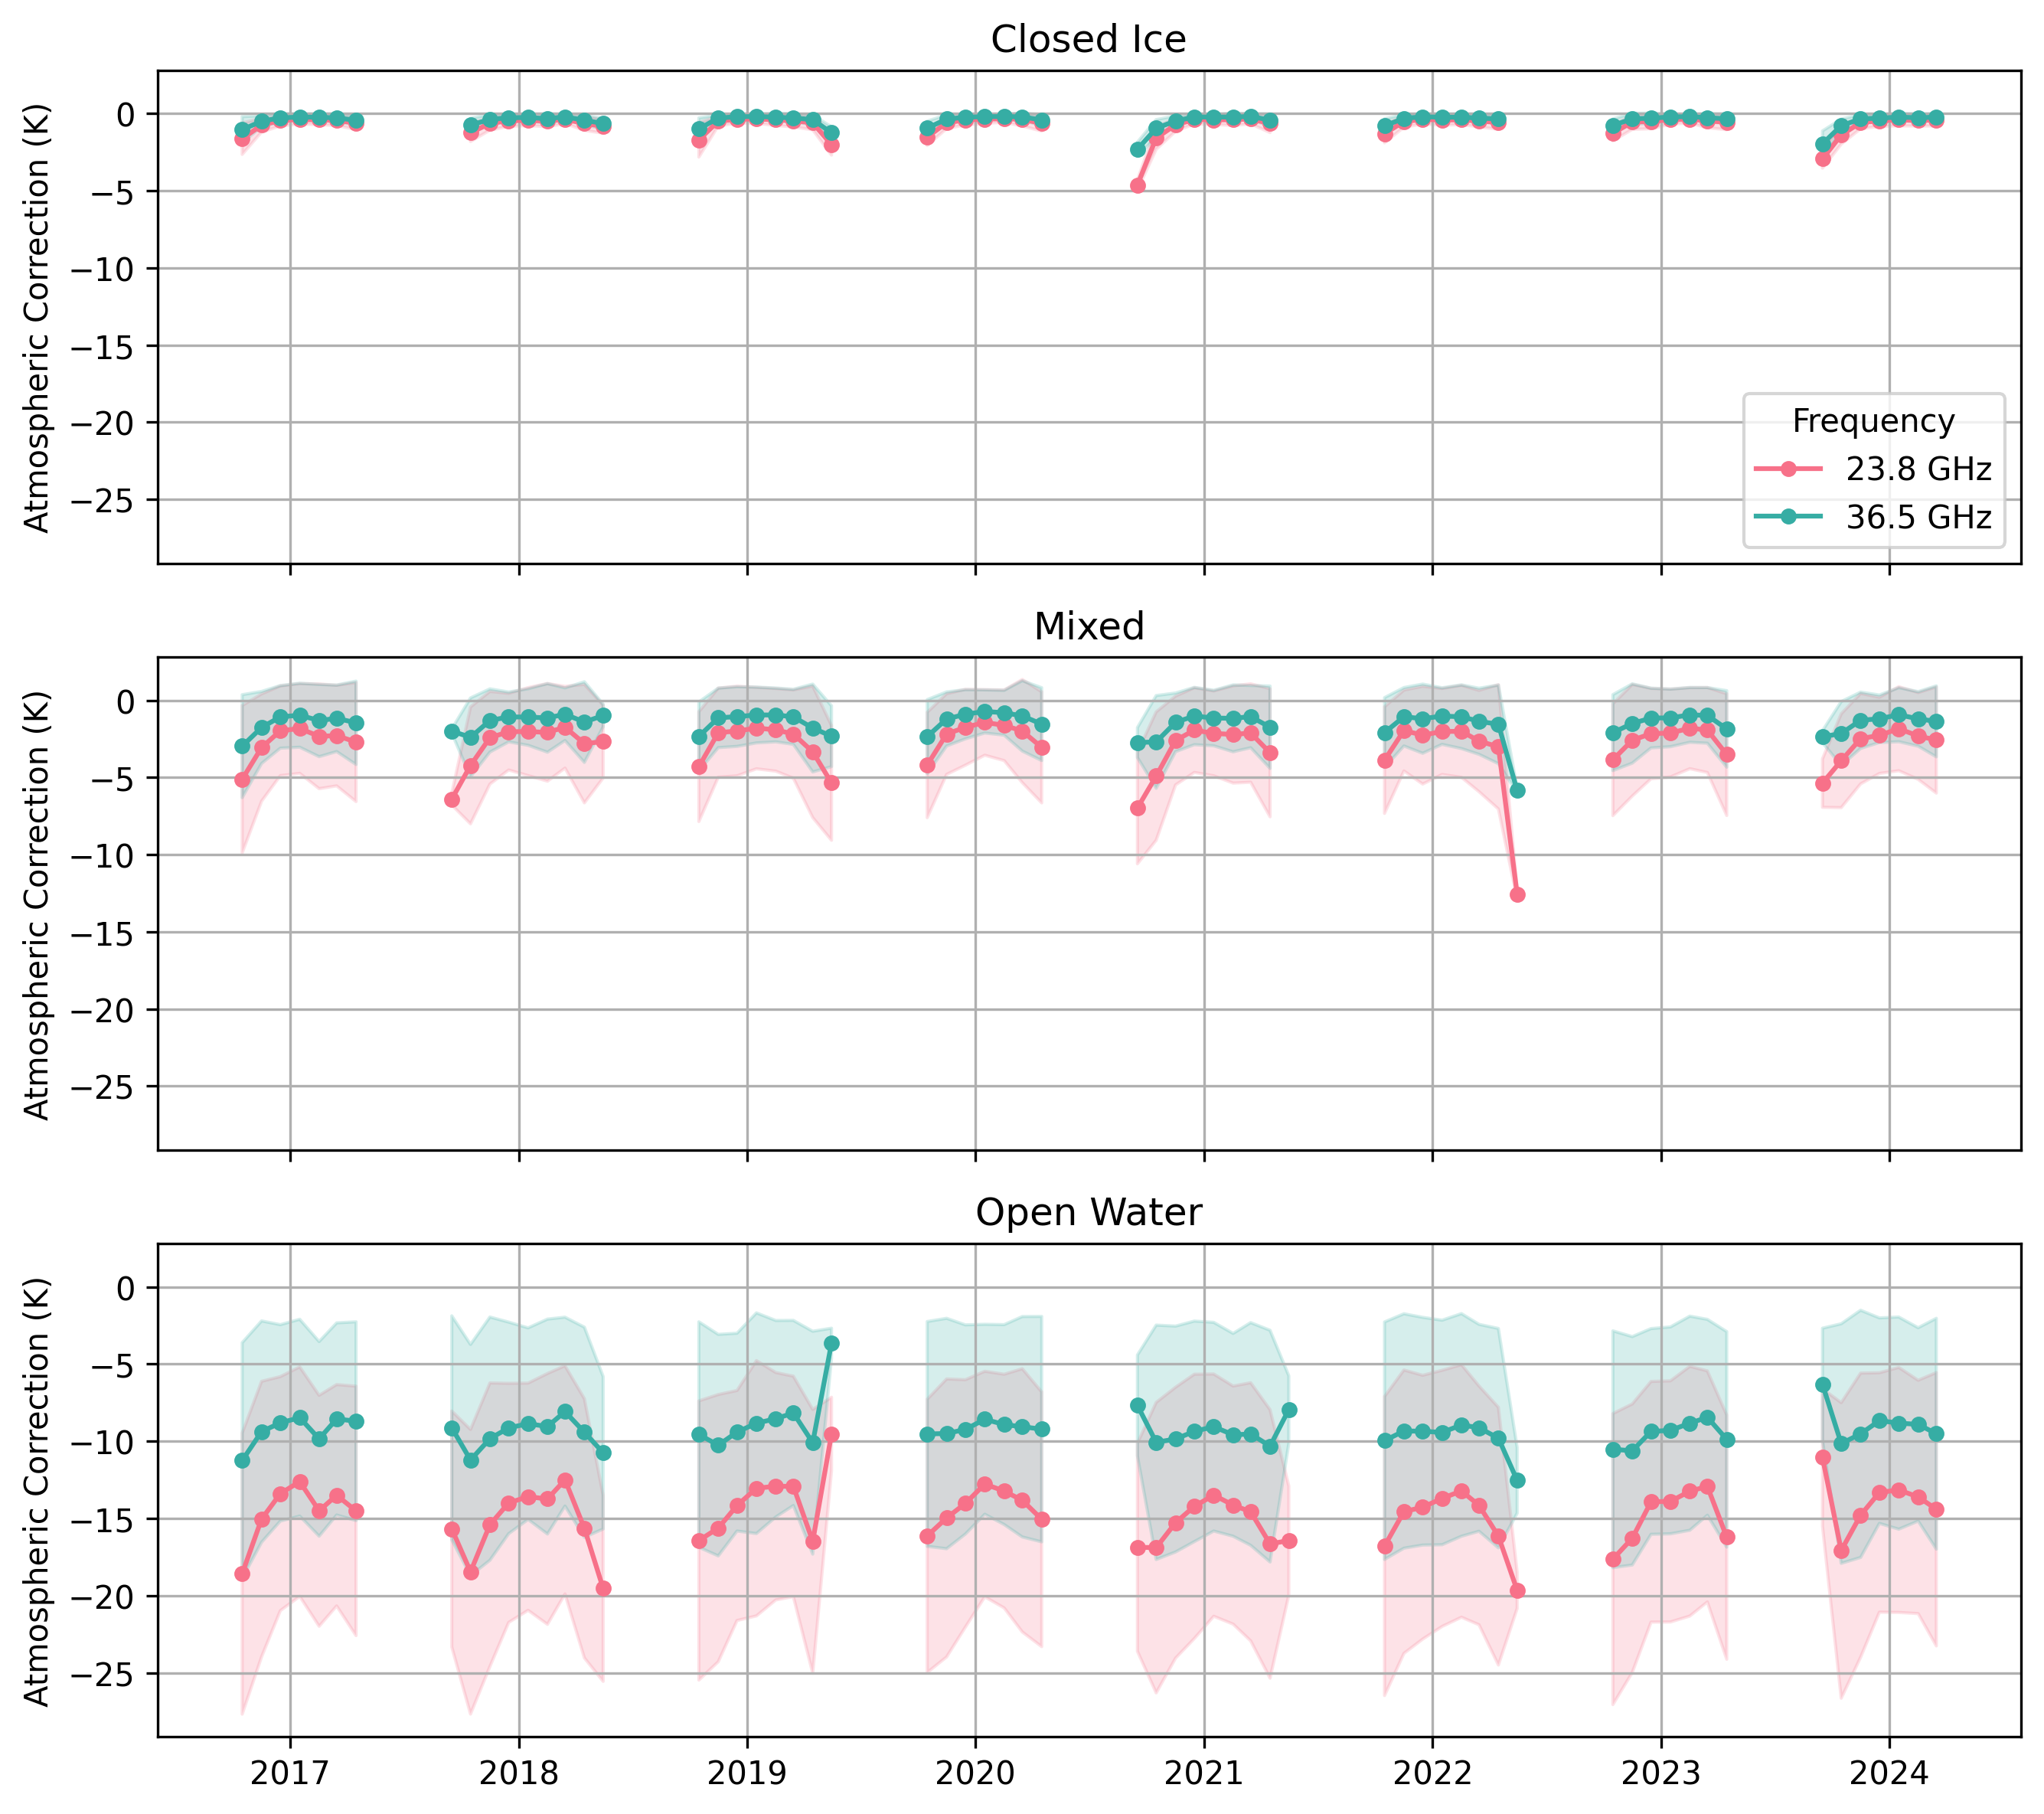

In [4]:
# plot the time series
surface_flags = monthly_df['Surface Flag'].unique()
colors = sns.color_palette("husl", 2)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True, dpi=300, sharey=True)
for i, flag in enumerate(surface_flags):
    ax = axes[i]
    for j, freq in enumerate(sorted(monthly_df['Frequency'].unique())):
        df_plot = monthly_df[(monthly_df['Surface Flag'] == flag) & (monthly_df['Frequency'] == freq)]
        ax.plot(pd.to_datetime(df_plot['Month_start'])+pd.Timedelta(days=15), df_plot['mean'], label=f'{freq} GHz', marker='o', linestyle='-', markersize=4, color=colors[j])
        ax.fill_between(pd.to_datetime(df_plot['Month_start'])+pd.Timedelta(days=15), df_plot['mean'] - df_plot['std'], df_plot['mean'] + df_plot['std'], alpha=0.2, color=colors[j])
    ax.set_title(f"{flag}")
    ax.set_ylabel('Atmospheric Correction (K)')
    if  i == 0:
        ax.legend(loc = 'lower right', title='Frequency', fontsize='medium')
    ax.grid(True)
plt.tight_layout()
plt.show()

## Tb Correction Statistics

In [5]:
seasonal_df = pd.read_csv(f'../Data/sentinel3_surface_mean_atmos_corr_{hemisphere}_above{min_lat}N.csv')
print(seasonal_df)

    Year  Frequency Surface Flag       mean     median       std         min  \
0   2016        238   Closed Ice  -0.540440  -0.407650  0.485679   -9.016293   
1   2016        238        Mixed  -2.774591  -1.433229  3.722289  -79.560486   
2   2016        238   Open Water -15.141383 -13.249136  8.505343 -125.325902   
3   2016        365   Closed Ice  -0.344262  -0.237069  0.361493   -8.916657   
4   2016        365        Mixed  -1.542182  -0.684012  2.550855  -79.350160   
5   2016        365   Open Water  -9.549474  -7.826095  6.929259 -111.668325   
6   2017        238   Closed Ice  -0.555631  -0.424967  0.445729   -6.523746   
7   2017        238        Mixed  -2.452198  -1.257726  3.206623  -85.865839   
8   2017        238   Open Water -15.235463 -13.160622  8.642117 -103.026895   
9   2017        365   Closed Ice  -0.339266  -0.238612  0.312929   -5.382142   
10  2017        365        Mixed  -1.320889  -0.592332  2.138966  -81.436098   
11  2017        365   Open Water  -9.622

In [6]:
overall_mean = seasonal_df.groupby(['Surface Flag', 'Frequency'])['mean'].mean()
#pooled standard deviation
overall_std = seasonal_df.groupby(['Surface Flag', 'Frequency']).apply(lambda x: np.sqrt(np.sum(x['std']**2) / len(x)))

overall_avg_table = pd.DataFrame({
    'Surface Flag': overall_mean.index.get_level_values('Surface Flag'),
    'Frequency': overall_mean.index.get_level_values('Frequency'),
    'Mean': overall_mean.values,
    'Std': overall_std.values
})

print(overall_avg_table)

  Surface Flag  Frequency       Mean       Std
0   Closed Ice        238  -0.514582  0.461143
1   Closed Ice        365  -0.307162  0.312573
2        Mixed        238  -2.550066  3.276892
3        Mixed        365  -1.364047  2.174275
4   Open Water        238 -15.065946  8.655979
5   Open Water        365  -9.531010  7.154847


/tmp/ipykernel_4080661/3894045570.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_std = seasonal_df.groupby(['Surface Flag', 'Frequency']).apply(lambda x: np.sqrt(np.sum(x['std']**2) / len(x)))


## Tb Correction Impact on OW Tie Point 

Here we'll show an example of how our atmospheric correction affects the open water tie point for a given day. Note, the tie point is simply the mean of the open water Tb samples taken from a ± 1 week window centered on the given date.

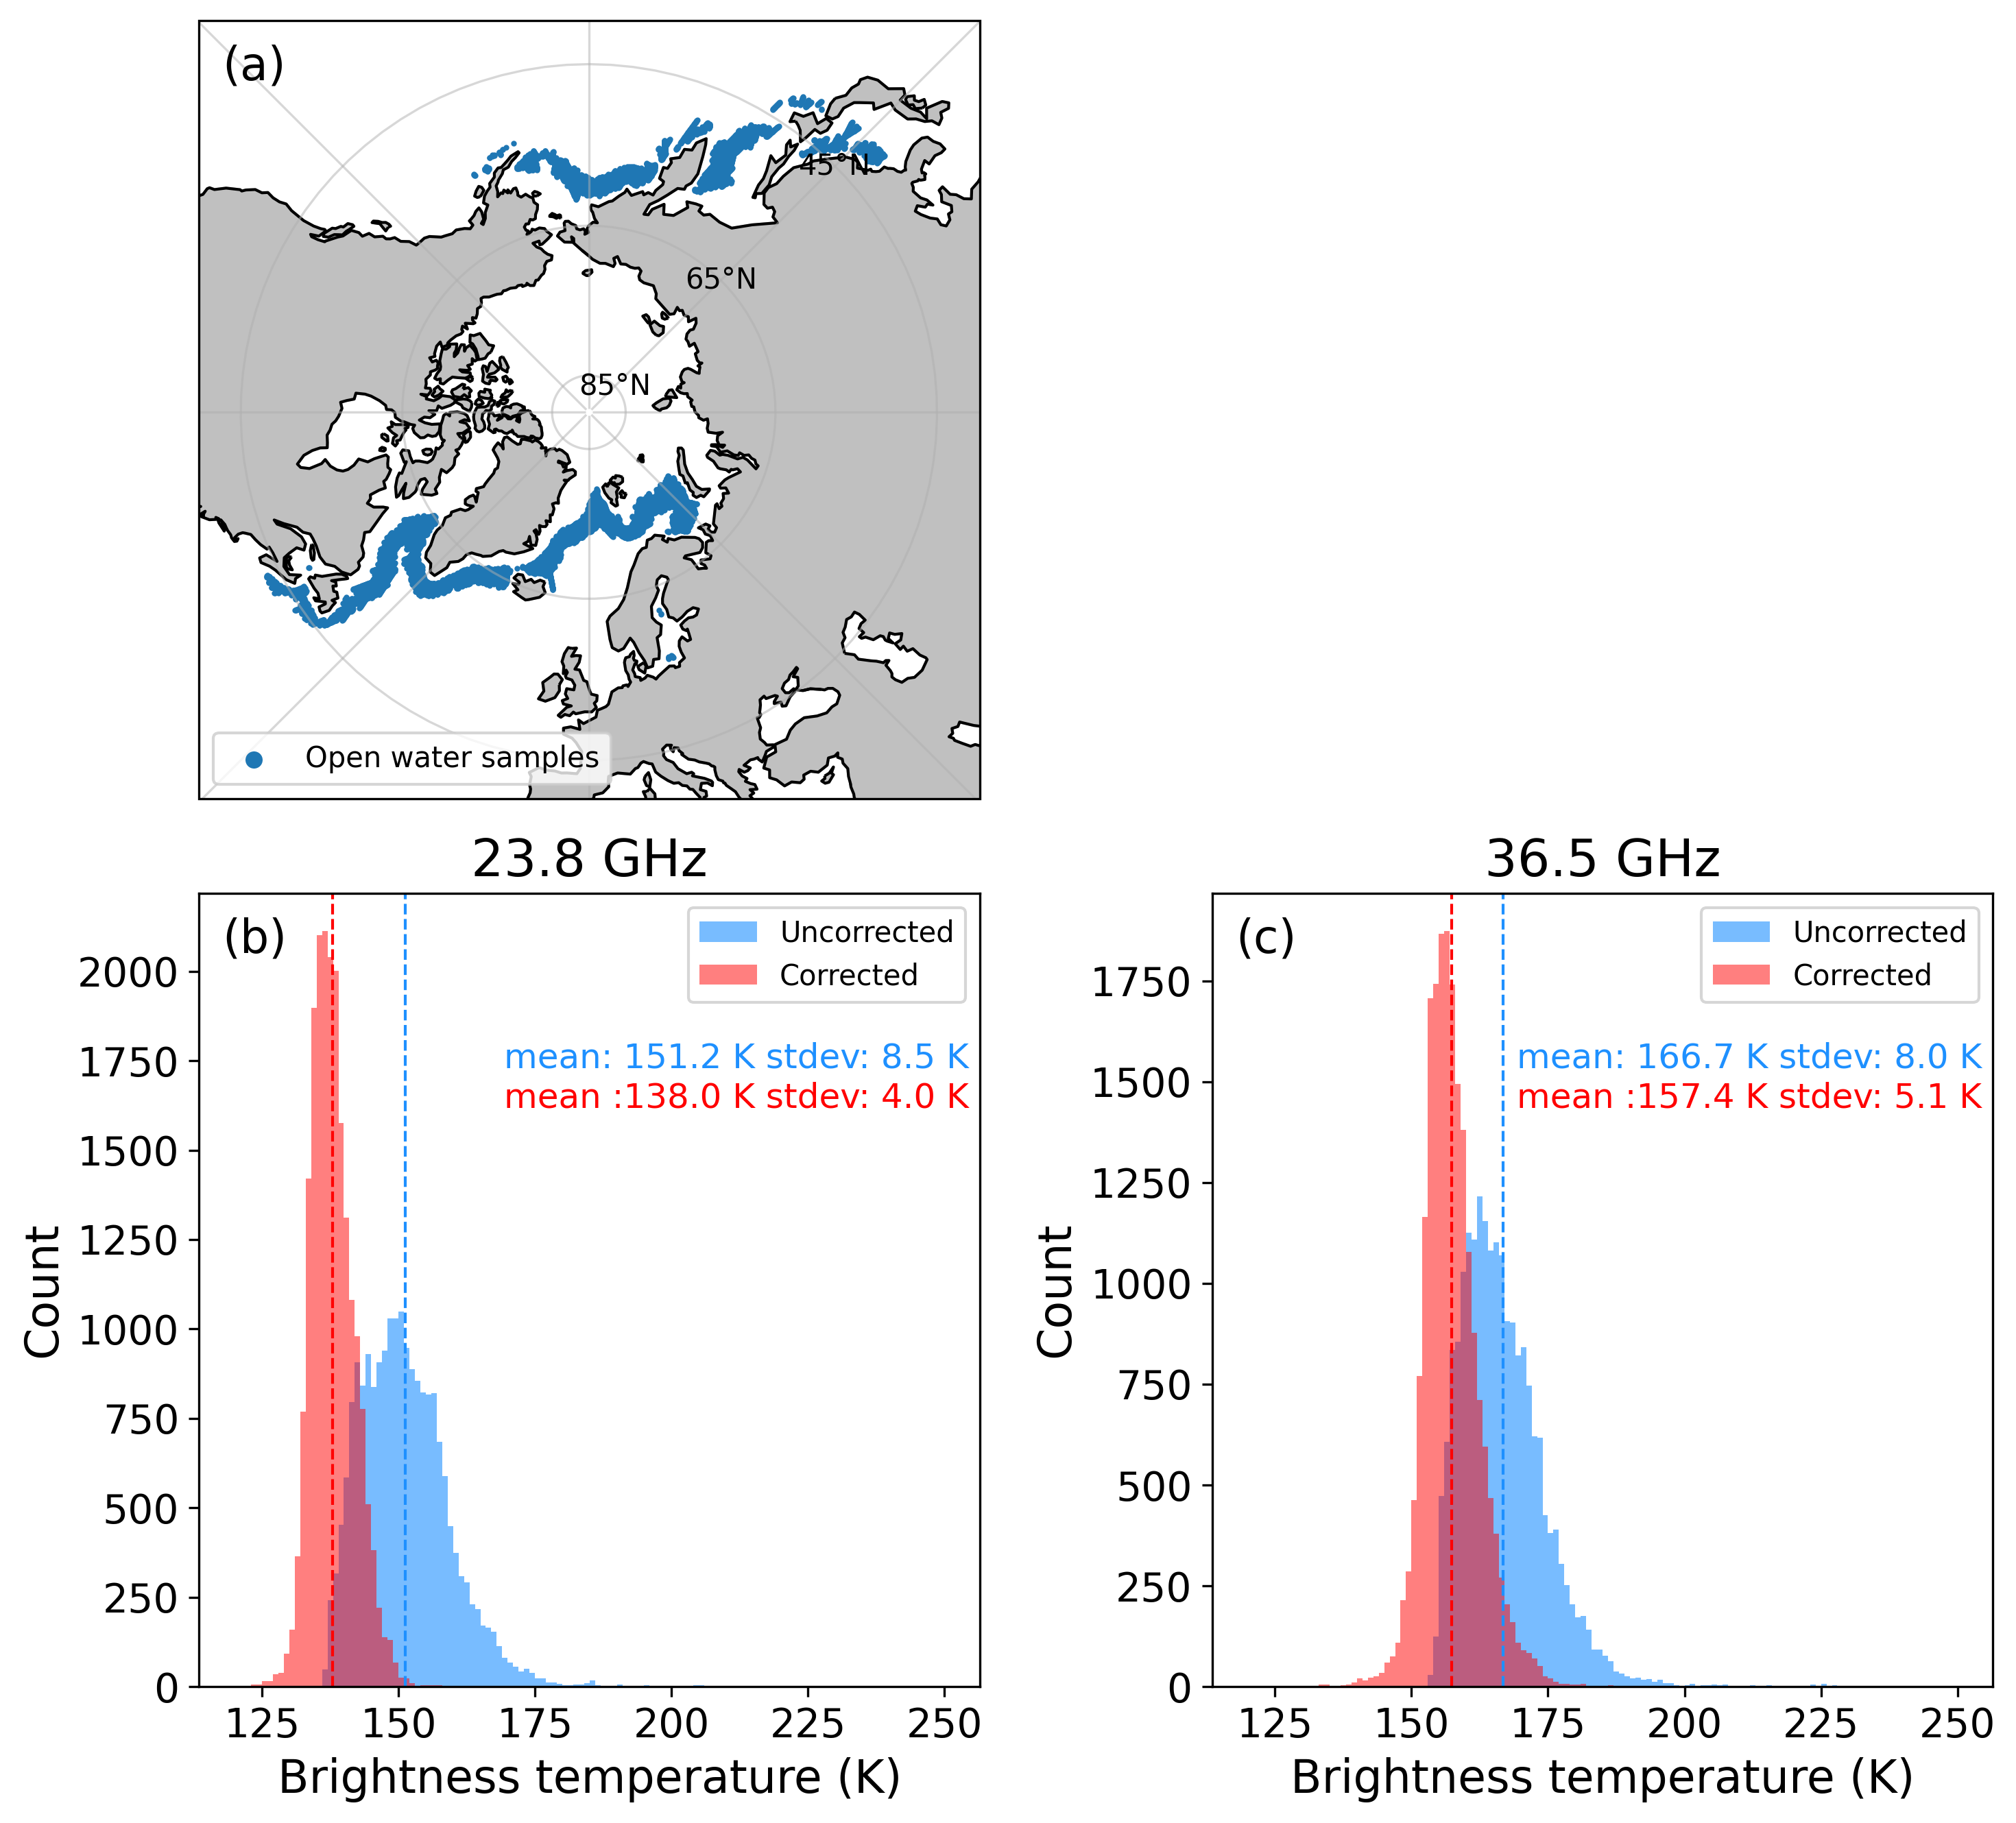

In [7]:
date = pd.to_datetime('2020-02-08')
hemisphere = 'nh'
tp_ds = get_tp_ds(date, hemisphere)
ow_ds = tp_ds.where(tp_ds['tp_type'] == 0, drop=True)

def get_tb_bin_edges(s3_ds, uncorrected=True, corrected=True):
    tb_vals = []
    if uncorrected:
       tb_vals.append(s3_ds[['tb_238_01', 'tb_365_01']].to_array())
    if corrected:
        tb_vals.append(s3_ds[['corr_tb_238_01', 'corr_tb_365_01']].to_array())
    tb_vals = np.concatenate(tb_vals)
    min_tb = np.floor(np.nanmin(tb_vals))
    max_tb = np.ceil(np.nanmax(tb_vals))
    bin_edges = np.arange(min_tb, max_tb, 1)
    return bin_edges

bin_edges = get_tb_bin_edges(ow_ds, uncorrected=True, corrected=True)
projection = ccrs.NorthPolarStereo()
extent = [-180, 180, 40, 90]
ylocs = [45, 65, 85]

fig = plt.figure(figsize=(10,9), dpi=300)
ax = fig.add_subplot(221, projection=projection)
ax.set_extent(extent, ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, color='silver')
ax.gridlines(draw_labels=True, dms=True, x_inline=True, y_inline=True, xlocs=[-135, -90, -45, 0 , 45, 90, 135, 180], ylocs=ylocs,alpha=0.5)
ax.scatter(ow_ds['lon_01'].values, ow_ds['lat_01'].values, s=1, transform=ccrs.PlateCarree(), label = 'Open water samples')
ax.text(0.03, 0.97, '(a)', transform=ax.transAxes, fontsize=16, va='top')
# theta = np.linspace(0, 2*np.pi, 100)
# center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
# circle = mpath.Path(verts * radius + center)
# ax.set_boundary(circle, transform=ax.transAxes)
ax.legend(loc='lower left', markerscale=5)
for i, (var, name) in enumerate(zip(['tb_238_01', 'tb_365_01'], ['23.8 GHz', '36.5 GHz'])):
    ax = fig.add_subplot(2,2,i+3)
    ax.hist(ow_ds[var].values.ravel(), bins=bin_edges, color='dodgerblue', alpha=0.6, label='Uncorrected')
    ax.axvline(ow_ds[var].mean().values, color='dodgerblue', linestyle='dashed', linewidth=1)
    ax.text(0.39, 0.78, f'mean: {ow_ds[var].mean().values:.1f} K stdev: {ow_ds[var].std().values:.1f} K', transform=ax.transAxes, color='dodgerblue', fontdict={'size': 12})
    ax.hist(ow_ds[f'corr_{var}'].values.ravel(), bins=bin_edges, color='red', alpha=0.5, label='Corrected')
    ax.axvline(ow_ds[f'corr_{var}'].mean().values, color='red', linestyle='dashed', linewidth=1)
    ax.text(0.39, 0.73, f'mean :{ow_ds[f"corr_{var}"].mean().values:.1f} K stdev: {ow_ds[f"corr_{var}"].std().values:.1f} K', transform=ax.transAxes, color='red', fontdict={'size': 12})
    ax.set_title(f'{name}', fontsize=18)
    ax.set_xlabel('Brightness temperature (K)', fontsize=16)
    ax.set_ylabel('Count', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_ylabel('Count')
    ax.legend(loc = 'upper right')
    ax.text(0.03, 0.97, f'({chr(98+i)})', transform=ax.transAxes, fontsize=16, va='top')
plt.tight_layout()
plt.savefig(f'ow_tp_map_inc_hists_{hemisphere}_{date.strftime("%Y%m%d")}.png')
plt.show()